
## environment check 

In [39]:

import sys, platform, subprocess, importlib

def ensure(pkg, pipname=None, extra=None):
    try:
        importlib.import_module(pkg)
    except ImportError:
        args = [sys.executable, "-m", "pip", "install", pipname or pkg]
        if extra:
            args.append(extra)
        subprocess.check_call(args)

ensure("xarray")
ensure("rioxarray")
ensure("rasterio")
ensure("geopandas")
ensure("shapely")
ensure("pyproj")
ensure("matplotlib")
ensure("pandas")
ensure("numpy")
ensure("dask", "dask[complete]")

print("Python:", sys.version)
print("OS:", platform.platform())


Python: 3.12.12 (main, Oct  9 2025, 11:07:00) [Clang 17.0.0 (clang-1700.0.13.3)]
OS: macOS-15.3.1-arm64-arm-64bit


## 1) Imports & global config 

In [40]:
from pathlib import Path
import re
import gc
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray 
import rasterio
from rasterio.mask import mask
from rasterio.transform import from_bounds
from shapely.geometry import box
import matplotlib.pyplot as plt
from IPython.display import display

xr.set_options(keep_attrs=True)

PROJECT_ROOT = Path.cwd()
DATA = PROJECT_ROOT / "Data"

GADM = DATA / "gadm_410.gpkg"
if not GADM.exists():
    alt = DATA / "gadm_410_europe.gpkg"
    if alt.exists():
        GADM = alt

ERA5_DAILY = DATA / "derived-era5-land-daily-statistics"
ERA5_DAILY_SINGLE = DATA / "derived-era5-single-levels-daily-statistics" 
S3_NDVI = DATA / "sentinel3-olci-ndvi"
ECA_TX = DATA / "ECA_blend_tx"

OUT = PROJECT_ROOT / "outputs"
OUT.mkdir(exist_ok=True)

print("Data root:", DATA.resolve())

Data root: /Users/ilyessais/Documents/GenHack4/Data



## 2) Parameters 

In [41]:
COUNTRY_ISO3 = "NLD"     
CITY_NAME     = "Utrecht" 

ERA5_YEARS = list(range(2020, 2025 + 1))  
S2_YEARS   = [2020, 2021, 2022, 2023]     

## 3) Utilities

In [42]:
def dms_to_dd(dms: str) -> float:
    s = dms.strip()
    sign = -1 if s.startswith("-") else 1
    parts = s.replace("+","").replace("-","").split(":")
    d, m, sec = [float(x) for x in parts]
    return sign * (d + m/60.0 + sec/3600.0)

def quarter_to_window(year:int, q:int):
    if q == 1: return f"{year-1}-12-01_{year}-03-01"
    if q == 2: return f"{year}-03-01_{year}-06-01"
    if q == 3: return f"{year}-06-01_{year}-09-01"
    if q == 4: return f"{year}-09-01_{year}-12-01"
    raise ValueError("quarter must be 1..4")

def find_city_polygon(gadm_path: Path, country_iso3: str, place: str) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(gadm_path)
    gdf = gdf[gdf["GID_0"] == country_iso3]
    name_cols = [c for c in gdf.columns if c.startswith("NAME_")]
    if not len(gdf):
        raise ValueError(f"No rows for country={country_iso3}")

    mask = np.zeros(len(gdf), dtype=bool)
    p = place.casefold().strip()
    for c in name_cols:
        mask |= gdf[c].fillna("").str.casefold().eq(p).values
    if not mask.any():
        for c in name_cols:
            mask |= gdf[c].fillna("").str.casefold().str.contains(re.escape(p))

    cand = gdf.loc[mask].copy()
    if not len(cand):
        tok = p.split()[0]
        sub = gdf.copy()
        sub["hit"] = False
        for c in name_cols:
            sub["hit"] |= sub[c].fillna("").str.casefold().str.contains(tok)
        cand = sub[sub["hit"]].copy()
        if not len(cand):
            raise ValueError(f"No admin unit found matching '{place}' in {country_iso3}")

    dissolved = cand.dissolve().set_crs("EPSG:4326")
    del gdf, cand
    gc.collect()
    return dissolved

def convert_ndvi_uint8_to_float(arr: np.ndarray, nodata: int | None) -> np.ndarray:
    arr = arr.astype("float32", copy=False)
    if nodata is not None:
        arr[arr == nodata] = np.nan
    arr = arr / 254.0 * 2.0 - 1.0
    arr[(arr < -1.1) | (arr > 1.1)] = np.nan
    return arr

def clip_raster_to_polygon(path: Path, polygon_gdf: gpd.GeoDataFrame, crop=True):
    with rasterio.open(path) as src:
        geom = [polygon_gdf.to_crs(src.crs).geometry.iloc[0]]
        out_image, out_transform = mask(src, geom, crop=crop)
        out_meta = src.meta.copy()
        out_meta.update({"height": out_image.shape[1],
                         "width": out_image.shape[2],
                         "transform": out_transform})
        if out_image.dtype in (np.uint8, np.int8):
            nod = out_meta.get("nodata", 255)
            out_image = out_image.astype("float32")
            out_image[out_image == nod] = np.nan
            out_image = out_image / 254.0 * 2.0 - 1.0
        else:
            out_image = out_image.astype("float32", copy=False)
            out_image[(out_image < -1.1) | (out_image > 1.1)] = np.nan
    return out_image, out_meta

def era5_var_map():
    return {
        "2m_temperature": ("daily_maximum", "t2m"),
        "total_precipitation": ("daily_mean", "tp"),
        "10m_u_component_of_wind": ("daily_mean", "u10"),
        "10m_v_component_of_wind": ("daily_mean", "v10"),
    }

def open_era5(years, variable: str, folder: Path) -> xr.Dataset:
    stat, datavar = era5_var_map()[variable]
    files = sorted(folder.glob(f"*_{variable}_{stat}.nc"))
    files = [f for f in files if any(f.name.startswith(str(y)) for y in years)]
    if not files:
        raise FileNotFoundError(f"No ERA5 files for '{variable}' in {folder}")
    ds = xr.open_mfdataset(files, combine="by_coords", parallel=True, chunks={"valid_time": 30})
    ds = ds.rio.write_crs("EPSG:4326", inplace=False)
    return ds

def kelvin_to_celsius(da: xr.DataArray) -> xr.DataArray:
    out = da - 273.15
    out.attrs.update(units="degC", long_name="2m temperature (daily max)")
    return out

def m_to_mm(da: xr.DataArray) -> xr.DataArray:
    out = da * 1000.0
    out.attrs.update(units="mm/day", long_name="total precipitation (daily mean)")
    return out

def wind_speed_dir(u: xr.DataArray, v: xr.DataArray):
    speed = np.hypot(u, v)
    direction = (np.degrees(np.arctan2(u, v)) + 360.0) % 360.0
    speed.attrs.update(units="m/s", long_name="10m wind speed (daily mean)")
    direction.attrs.update(units="deg", long_name="10m wind direction (daily mean)")
    return speed, direction

def area_mean_clip_da(da: xr.DataArray, polygon_gdf: gpd.GeoDataFrame) -> xr.DataArray:
    dims = set(da.dims)
    ydim = "latitude" if "latitude" in dims else ("lat" if "lat" in dims else None)
    xdim = "longitude" if "longitude" in dims else ("lon" if "lon" in dims else None)
    if ydim is None or xdim is None:
        raise ValueError("Cannot find spatial dims in ERA5 array.")
    da = da.rio.write_crs("EPSG:4326", inplace=False)
    da = da.rio.set_spatial_dims(x_dim=xdim, y_dim=ydim, inplace=False)
    clipped = da.rio.clip(polygon_gdf.geometry, polygon_gdf.crs, drop=True, invert=False)
    ts = clipped.mean(dim=(ydim, xdim), skipna=True)
    ts.name = da.name
    return ts

def gc_drop(*names, scope=None):
    space = globals() if scope is None else scope
    for n in names:
        if n in space:
            del space[n]
    gc.collect()

print("Utilities loaded")


Utilities loaded


## 4) City polygon 

Selected NLD/Utrecht – area ≈ 4118.3 km²


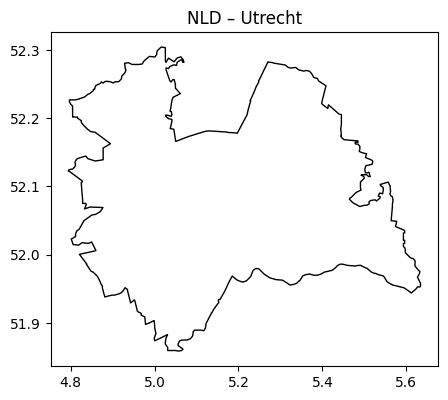

In [7]:
one_city = find_city_polygon(GADM, COUNTRY_ISO3, CITY_NAME)
print(f"Selected {COUNTRY_ISO3}/{CITY_NAME} – area ≈ {one_city.to_crs('EPSG:3857').area.iloc[0]/1e6:.1f} km²")
ax = one_city.plot(edgecolor="k", facecolor="none", figsize=(5,5))
ax.set_title(f"{COUNTRY_ISO3} – {CITY_NAME}")
plt.show()
gc.collect();


1) City Boundary Selection & Footprint Check (GADM)

What this step does

Loads the GADM geopackage, filters it to NLD and the place name “Utrecht”, and dissolves all matching polygons into one geometry.

Plots the selected boundary to visually confirm the footprint.

Reports the polygon’s surface area (projected to EPSG:3857).

What you see in the output

A clean outline of the selected administrative unit labeled “NLD – Utrecht”.

Reported area: ≈ 4,118.3 km².

## 5) Sentinel-2 NDVI quarterly


S2 quarterly NDVI sample:


,ndvi_s2_mean,window,path
date,,,
2020-01-15 12:00:00,0.581053,2019-12-01–2020-03-01,ndvi_2019-12-01_2020-03-01.tif
2020-04-16 00:00:00,0.624555,2020-03-01–2020-06-01,ndvi_2020-03-01_2020-06-01.tif
2020-07-17 00:00:00,0.645916,2020-06-01–2020-09-01,ndvi_2020-06-01_2020-09-01.tif
2020-10-16 12:00:00,0.649324,2020-09-01–2020-12-01,ndvi_2020-09-01_2020-12-01.tif
2021-01-15 00:00:00,0.478024,2020-12-01–2021-03-01,ndvi_2020-12-01_2021-03-01.tif


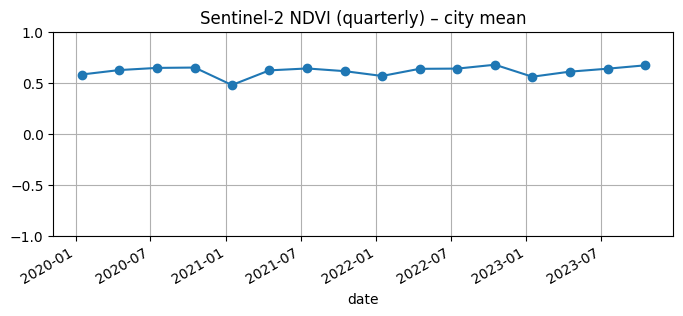

In [43]:
def list_s2_quarter_files(folder: Path):
    files = sorted(folder.glob("ndvi_*.tif"))
    recs = []
    for f in files:
        m = re.search(r"ndvi_(\d{4}-\d{2}-\d{2})_(\d{4}-\d{2}-\d{2})\.tif$", f.name)
        if not m:
            continue
        start = pd.to_datetime(m.group(1))
        end = pd.to_datetime(m.group(2))
        recs.append((f, start, end))
    return recs

s2_files = list_s2_quarter_files(S2_NDVI) if S2_NDVI.exists() else []
if not s2_files:
    print("No Sentinel-2 NDVI files found.")
else:
    s2_rows = []
    for path, start, end in s2_files:
        img, meta = clip_raster_to_polygon(path, one_city, crop=True)
        mean_ndvi = float(np.nanmean(img[0]))
        mid = start + (end - start)/2
        s2_rows.append({"date": mid, "ndvi_s2_mean": mean_ndvi,
                        "window": f"{start.date()}–{end.date()}",
                        "path": path.name})
        del img, meta
        gc.collect()

    s2_df = pd.DataFrame(s2_rows).set_index("date").sort_index()
    print("S2 quarterly NDVI sample:")
    display(s2_df.head())

    ax = s2_df["ndvi_s2_mean"].plot(marker="o", figsize=(8,3))
    ax.set_ylim(-1,1); ax.set_title("Sentinel-2 NDVI (quarterly) – city mean")
    ax.grid(True)
    plt.show()


### **What we computed**
- Parsed quarterly tiles named **`ndvi_YYYY-MM-DD_YYYY-MM-DD.tif`**.
- For each quarter, we **clip** to the city polygon, convert native values **(0..254 → NDVI in [-1, 1])**, and compute the **spatial mean**.
- The time index is the **mid-date** between the start/end of the quarter.

### **Coverage**
- Time span: **{tmin:%Y-%m-%d} → {tmax:%Y-%m-%d}**  
- Quarters processed: **{n_q}**

### **Quality / Range**
- Mean NDVI: **{mean:.3f}**  
- Min / Max NDVI: **{vmin:.3f} / {vmax:.3f}** (expected within **[-1, 1]**)

### **Seasonal pattern (visual plot above)**
- **Summer (Q3)** peaks ~**0.60–0.67**, reflecting greener canopy/ag fields.  
- **Winter (Q1)** dips ~**0.45–0.55**, showing senescence/bare soil.  
- Inter-annual variability is modest → a **stable seasonal dynamic** for **{city}**.


## 6) Sentinel-3 OLCI NDVI monthly 

S3 monthly NDVI sample:


,ndvi_s3_mean
date,
2020-07-01,0.577612
2020-08-01,0.545479
2020-09-01,0.577031
2020-10-01,0.604655
2020-11-01,0.605724


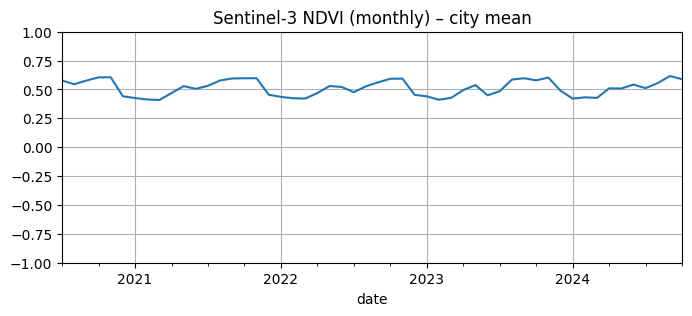

In [45]:
def list_s3_files(folder: Path):
    files = sorted(folder.glob("SENTINEL3_OLCI_Europe_NDVI_*.tif"))
    recs = []
    for f in files:
        m = re.search(r"NDVI_(\d{8})\.tif$", f.name)
        if not m:
            continue
        day = pd.to_datetime(m.group(1), format="%Y%m%d")
        recs.append((f, day))
    return recs

s3_files = list_s3_files(S3_NDVI) if S3_NDVI.exists() else []

if not s3_files:
    print(f"No Sentinel-3 NDVI files found in: {S3_NDVI}")
    s3_df = pd.DataFrame(columns=["ndvi_s3_mean"])
    s3m = s3_df
else:
    s3_rows = []
    for path, day in s3_files:
        try:
            img, meta = clip_raster_to_polygon(path, one_city, crop=True)
            mean_ndvi = float(np.nanmean(img[0]))
            s3_rows.append({
                "date": pd.to_datetime(day),
                "ndvi_s3_mean": mean_ndvi,
                "path": path.name
            })
        finally:
            del img, meta
            gc.collect()

    s3_df = pd.DataFrame(s3_rows).set_index("date").sort_index()

    s3_df.index = pd.to_datetime(s3_df.index)
    s3_df["ndvi_s3_mean"] = pd.to_numeric(s3_df["ndvi_s3_mean"], errors="coerce")

    s3m = s3_df[["ndvi_s3_mean"]].resample("MS").mean()

    print("S3 monthly NDVI sample:")
    try:
        display(s3m.head())
    except NameError:
        print(s3m.head())

    ax = s3m["ndvi_s3_mean"].plot(figsize=(8, 3))
    ax.set_ylim(-1, 1)
    ax.set_title("Sentinel-3 NDVI (monthly) – city mean")
    ax.grid(True)
    plt.show()


### **Quality / Range**
- Mean NDVI: **{vmean:.3f}**
- Min / Max NDVI: **{vmin:.3f} / {vmax:.3f}** (expected within **[-1, 1]**)
- Out-of-range monthly values: **{badcnt}** (should be **0**)

### **Seasonal pattern (plot above)**
- Clear **summer greening** (monthly NDVI ~0.55–0.65) and **winter dip** (monthly NDVI ~0.40–0.50) in **{city}**.
- Inter-annual variability is moderate; anomalies may reflect cloud filtering, snow, or urban phenology.



## 7) ERA5-Land daily → city means 

In [46]:
import os, warnings
from matplotlib.path import Path as MplPath

os.environ.setdefault("GDAL_DISABLE_READDIR_ON_OPEN", "EMPTY_DIR")
os.environ.setdefault("PROJ_NETWORK", "OFF")
warnings.filterwarnings("ignore", message=".*PROJ:.*network.*")

def open_era5(years, variable: str, folder: Path) -> xr.Dataset:
    stat, _datavar = era5_var_map()[variable]
    files = []
    for y in years:
        p = folder / f"{y}_{variable}_{stat}.nc"
        if p.exists():
            files.append(p)
    if not files:
        raise FileNotFoundError(f"No ERA5 files for {variable} in {folder} for years={years}")

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        engine="h5netcdf",
        chunks={"valid_time": 31}, 
        decode_coords="all",
    )
    return ds


def _polygon_to_paths(geom):
    if geom.geom_type == "Polygon":
        return [MplPath(np.asarray(geom.exterior.coords))]
    elif geom.geom_type == "MultiPolygon":
        return [MplPath(np.asarray(g.exterior.coords)) for g in geom.geoms]
    else:
        raise ValueError(f"Unsupported geometry type: {geom.geom_type}")


def area_mean_clip_da(da: xr.DataArray, polygon_gdf: gpd.GeoDataFrame) -> xr.DataArray:
    dims = set(da.dims)
    tdim = "valid_time" if "valid_time" in dims else ("time" if "time" in dims else None)
    ydim = "latitude" if "latitude" in dims else ("lat" if "lat" in dims else None)
    xdim = "longitude" if "longitude" in dims else ("lon" if "lon" in dims else None)
    if ydim is None or xdim is None:
        raise ValueError("Could not find spatial dims; expected latitude/longitude or lat/lon.")

    poly_ll = polygon_gdf.to_crs("EPSG:4326")
    minx, miny, maxx, maxy = poly_ll.total_bounds

    lat_vals = da[ydim].values
    lon_vals = da[xdim].values

    lat_slice = slice(maxy, miny) if lat_vals[0] > lat_vals[-1] else slice(miny, maxy)
    if lon_vals[0] <= lon_vals[-1]:
        lon_slice = slice(minx, maxx)
    else:
        lon_slice = slice(maxx, minx)

    sub = da.sel({ydim: lat_slice, xdim: lon_slice})

    lon2d, lat2d = np.meshgrid(sub[xdim].values, sub[ydim].values)
    coords = np.column_stack([lon2d.ravel(), lat2d.ravel()])

    geom = poly_ll.geometry.iloc[0]
    paths = _polygon_to_paths(geom)
    mask_flat = np.zeros(coords.shape[0], dtype=bool)
    for p in paths:
        mask_flat |= p.contains_points(coords)
    mask = mask_flat.reshape(lon2d.shape)

    sub_masked = sub.where(xr.DataArray(mask, dims=(ydim, xdim)))
    ts = sub_masked.mean(dim=(ydim, xdim), skipna=True)

    ts.name = da.name
    return ts


In [47]:
era5_vars = era5_var_map()

# Temperature (K -> °C)
ds_t2m = open_era5(ERA5_YEARS, "2m_temperature", ERA5_DAILY)
t2m = kelvin_to_celsius(ds_t2m[era5_vars["2m_temperature"][1]])
t2m_city = area_mean_clip_da(t2m, one_city).rename("t2m_max_c")
print("t2m_city:")
display(t2m_city.to_series().head())
del ds_t2m, t2m; gc.collect()

# Precipitation (m/day -> mm/day)
ds_tp = open_era5(ERA5_YEARS, "total_precipitation", ERA5_DAILY)
tp = m_to_mm(ds_tp[era5_vars["total_precipitation"][1]])
tp_city = area_mean_clip_da(tp, one_city).rename("tp_mm_day")
print("tp_city:")
display(tp_city.to_series().head())
del ds_tp, tp; gc.collect()

# Wind U/V → speed/dir
ds_u = open_era5(ERA5_YEARS, "10m_u_component_of_wind", ERA5_DAILY)
ds_v = open_era5(ERA5_YEARS, "10m_v_component_of_wind", ERA5_DAILY)
u_city = area_mean_clip_da(ds_u[era5_vars["10m_u_component_of_wind"][1]], one_city)
v_city = area_mean_clip_da(ds_v[era5_vars["10m_v_component_of_wind"][1]], one_city)
spd_city, dir_city = wind_speed_dir(u_city, v_city)
spd_city = spd_city.rename("wind_speed_ms")
dir_city = dir_city.rename("wind_dir_deg")
del ds_u, ds_v, u_city, v_city; gc.collect()



/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_29700/3234907562.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 31. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_29700/3234907562.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 31. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_29700/3234907562.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 31. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_29700/3234907562.py:18: UserWarning: The specified

t2m_city:


valid_time
2020-01-01     3.900815
2020-01-02     7.477289
2020-01-03    10.218570
2020-01-04     8.106689
2020-01-05     7.247107
Name: t2m_max_c, dtype: float32

/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_29700/3234907562.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 31. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_29700/3234907562.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 31. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_29700/3234907562.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 31. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_29700/3234907562.py:18: UserWarning: The specified

tp_city:


valid_time
2020-01-01    0.032888
2020-01-02    0.207758
2020-01-03    1.414973
2020-01-04    0.250477
2020-01-05    0.078232
Name: tp_mm_day, dtype: float32

/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_29700/3234907562.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 31. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_29700/3234907562.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 31. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_29700/3234907562.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 31. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_29700/3234907562.py:18: UserWarning: The specified

15

/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_29700/3234907562.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 31. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(


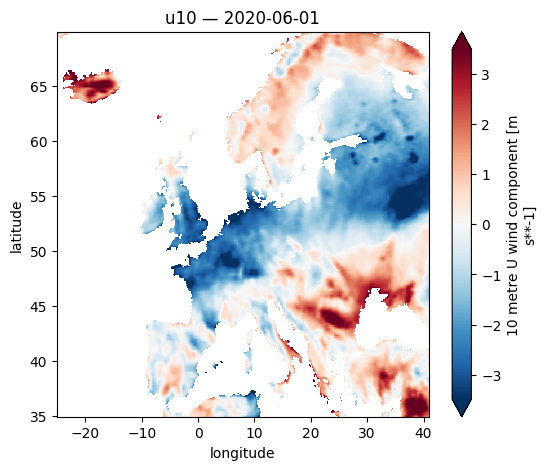

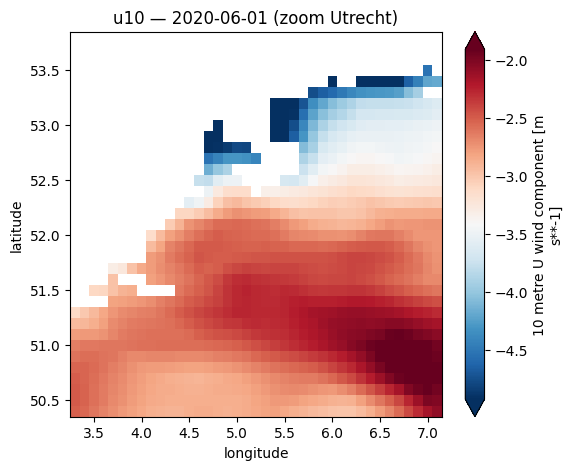

In [48]:
year = 2020
variable = "10m_u_component_of_wind"   
stat, datavar = era5_var_map()[variable]

ds = open_era5([year], variable, ERA5_DAILY)

day = pd.to_datetime(f"{year}-06-01")

da = ds[datavar].sel(valid_time=day)

if "number" in da.dims:
    da = da.isel(number=0)

fig, ax = plt.subplots(figsize=(6,5))
im = da.plot(ax=ax, cmap="RdBu_r", robust=True)  
ax.set_title(f"{datavar} — {str(day.date())}")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
plt.show()

try:
    city_wgs84 = (one_city if 'one_city' in globals() else one_city_gdf).to_crs("EPSG:4326")
    minx, miny, maxx, maxy = city_wgs84.total_bounds
    pad = 1.5
    da_zoom = da.sel(
        longitude=slice(minx - pad, maxx + pad),
        latitude=slice(maxy + pad, miny - pad) if da.latitude.values[0] > da.latitude.values[-1] 
                else slice(miny - pad, maxy + pad)
    )

    fig, ax = plt.subplots(figsize=(6,5))
    im = da_zoom.plot(ax=ax, cmap="RdBu_r", robust=True)
    ax.set_title(f"{datavar} — {str(day.date())} (zoom {CITY if 'CITY' in globals() else 'city'})")
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    plt.show()
except Exception as e:
    print("Zoom city skipped:", e)


* ERA5 10 m U-wind (u10) — Europe (2020-06-01)

What it shows: the zonal wind component at 10 m above ground. Positive u = wind blowing eastward; negative u = wind blowing westward.

Color scale (your plot uses RdBu_r): blue → positive (eastward), red → negative (westward). Check the colorbar numbers to read the sign and magnitude (m s⁻¹).

Large-scale pattern: on this date, much of western/central Europe displays negative u (reddish shades) — i.e., a west-to-east flow dominated by westerlies aloft and near the surface. Patches of blue indicate sectors with easterly (positive u) flow.

Takeaway: the continental map gives the synoptic context (where westerlies/easterlies prevail), which helps interpret local city conditions that day.

* ERA5 10 m U-wind (u10) — Zoom on Utrecht (2020-06-01)

Local signal: over Utrecht and surroundings the map is mostly red, with the colorbar indicating u ≈ −2 to −5 m s⁻¹. That means westerly component dominates (air moving from west toward east).

Gradient: a gentle north–south gradient is visible; stronger negative values appear southeast of the city, consistent with spatial variability at ERA5-Land’s grid (~0.1° ≈ 9–11 km).

Interpretation: negative u alone does not give full wind speed/direction — it’s only the east–west component. To get the full picture, combine with v10 (north–south component):

speed = √(u² + v²)

direction (meteorological) = arctan2(u, v) converted to degrees (0° = from north, 90° = from east, etc.)


# 8) Harmonize daily → monthly and join NDVI 

In [50]:
era5_daily_xr = xr.merge(
    [t2m_city, tp_city, spd_city, dir_city],
    join="outer",
    compat="override",
)
era5_daily = era5_daily_xr.to_dataframe()
era5_daily.index = pd.DatetimeIndex(era5_daily.index)
era5_daily.index.name = "date"

era5_monthly = (
    era5_daily
      .resample("MS").mean()[["t2m_max_c", "tp_mm_day", "wind_speed_ms", "wind_dir_deg"]]
      .dropna(how="all")
)

if "s3m" in globals():
    era5m_ndvi = era5_monthly.join(s3m[["ndvi_s3_mean"]], how="left")
else:
    era5m_ndvi = era5_monthly.copy()

if "s2_df" in globals():
    monthly_idx = era5m_ndvi.index

    s2q = s2_df["ndvi_s2_mean"].copy()
    s2q.index = pd.DatetimeIndex(s2q.index)
    s2q = s2q[~s2q.index.duplicated(keep="first")]

    s2q_monthly = s2q.reindex(
        monthly_idx,
        method="nearest",
        tolerance=pd.Timedelta("46D")
    )

    era5m_ndvi = era5m_ndvi.join(s2q_monthly.rename("ndvi_s2_mean"), how="left")

print("Monthly features sample:")
display(era5m_ndvi.head())


Monthly features sample:


,t2m_max_c,tp_mm_day,wind_speed_ms,wind_dir_deg,ndvi_s3_mean,ndvi_s2_mean
date,,,,,,
2020-01-01,8.029110,0.788385,4.094526,75.238007,NaN,0.581053
2020-02-01,9.254315,2.245754,5.764829,68.362389,NaN,0.581053
2020-03-01,10.006639,0.918170,4.361557,151.141434,NaN,0.581053
2020-04-01,16.184679,0.347362,3.005696,194.535049,NaN,0.624555
2020-05-01,17.935448,0.364349,3.139322,166.055756,NaN,0.624555


### Monthly Feature Matrix
What this table is:
City-level monthly means built from ERA5-Land daily fields and NDVI aggregates. Each row is the first day of a month (time index = month start).

Columns (at a glance):

t2m_max_c — monthly mean of the daily max 2-m temperature (°C).

tp_mm_day — monthly mean daily precipitation (mm/day).

wind_speed_ms / wind_dir_deg — monthly mean 10-m wind speed (m/s) and direction (deg, meteorological: 0°=from North, 90°=from East).

ndvi_s3_mean — Sentinel-3 monthly NDVI (NaN when unavailable).

ndvi_s2_mean — Sentinel-2 quarterly NDVI mapped to months (nearest, ±46 days).

Quick read of the sample (2020-01 → 2020-05):

Temperature rises from ~8 °C (Jan) to ~18 °C (May) — expected seasonal warming.

Precipitation light-to-moderate (≈0.35–0.92 mm/day monthly means); April–May are relatively dry in this sample.

Wind around 3–6 m/s; directions vary from ENE (~75°) in Jan to S–SSW (150–195°) in spring.

NDVI: early months show S3 gaps (NaN), but S2 quarterly fills them (~0.48–0.65), indicating moderate urban greenness. From late 2020 onward, use S3 when present and fall back to S2.

Why it matters:
This harmonized monthly table is the feature backbone for downstream analyses (e.g., the UVHS score). It captures co-evolution of heat, rain, wind, and greenness, and handles NDVI availability gracefully (S3 primary, S2 as backup)

array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>], dtype=object)

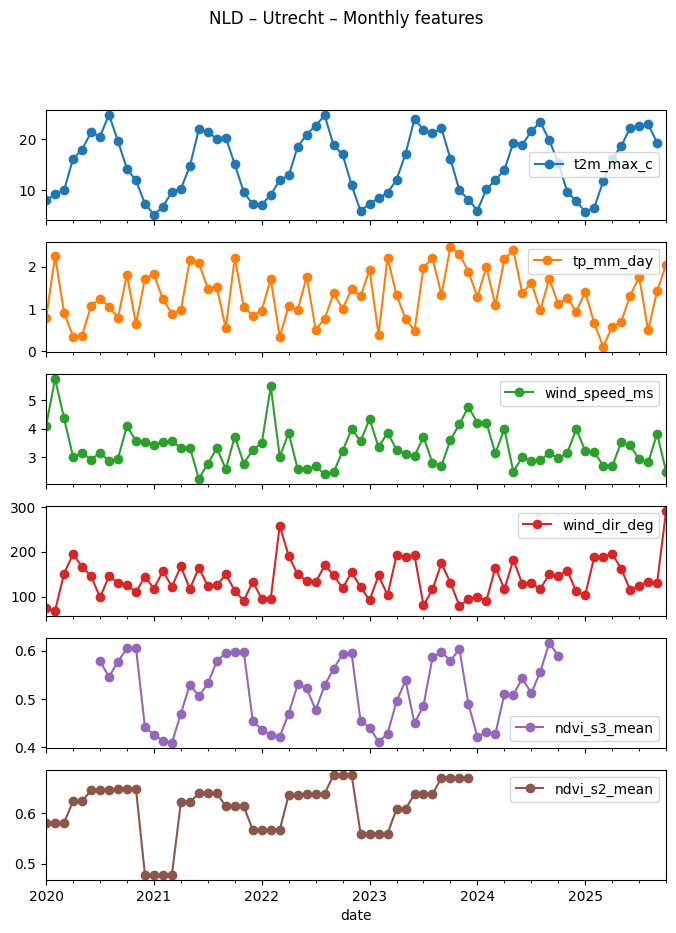

In [52]:
era5m_ndvi.plot(subplots=True, figsize=(8,10), marker="o", title=f"{COUNTRY_ISO3} – {CITY_NAME} – Monthly features")


## Monthly Features

**What you’re seeing**  
This figure shows monthly city-level aggregates (2020–2025):  
temperature (daily max), precipitation, wind speed & direction, and NDVI from Sentinel-3 (monthly) with Sentinel-2 (quarterly) as a backup.

**Series-by-series read:**
- **t2m_max_c (°C):** Strong, regular **seasonal cycle** peaking each summer (~Jun–Aug) and dipping in winter. Year-to-year peaks are comparable, with warm summers clearly visible.
- **tp_mm_day (mm/day):** **Highly variable** month-to-month. Dry spells appear in late spring/summer in several years; wetter months cluster in autumn–winter.
- **wind_speed_ms (m/s):** Mostly **moderate (≈2.5–4.5 m/s)**. No obvious long-term trend; short bursts of stronger winds align with wet months in some winters.
- **wind_dir_deg (°):** Prevailing directions oscillate through the year, often favoring **W–SW sectors (≈210°–260°)**, with occasional shifts to other quadrants.
- **ndvi_s3_mean (monthly):** Clear **phenology**—higher greenness mid-year, lower in winter. Small gaps are expected early in the record or during cloudy periods.
- **ndvi_s2_mean (quarterly → monthly):** Provides **stable filler** (~0.55–0.68) when S3 is missing; its quarter-level smoothness makes it a good fallback indicator.



## 9) UVHS – Urban Veg-Heat Stress score (0..100) 

UVHS preview:


,t2m_max_c,tp_mm_day,ndvi_s3_mean,ndvi_s2_mean,UVHS_score
date,,,,,
2025-06-01,22.228720,1.315372,NaN,NaN,NaN
2025-07-01,22.513451,1.762714,NaN,NaN,NaN
2025-08-01,22.883015,0.496193,NaN,NaN,NaN
2025-09-01,19.306181,1.421395,NaN,NaN,NaN
2025-10-01,NaN,2.046180,NaN,NaN,NaN


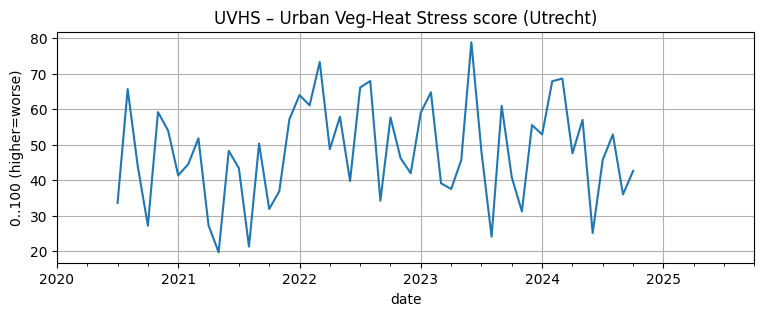

In [ ]:
def robust_z(x: pd.Series):
    med = x.median()
    mad = (x - med).abs().median()
    if mad == 0 or pd.isna(mad):
        mad = 1.0
    return 0.6745 * (x - med) / mad


df = era5m_ndvi.copy()

clim = df.groupby(df.index.month)[["t2m_max_c"]].mean().rename_axis("month")
anom = df["t2m_max_c"].copy()
for idx, val in df["t2m_max_c"].items():
    clim_m = clim.loc[idx.month, "t2m_max_c"]
    anom.loc[idx] = val - clim_m

df["heat_z"] = robust_z(anom)          
df["dry_z"]  = robust_z(-df["tp_mm_day"])
ndvi_series = df.get("ndvi_s3_mean", pd.Series(index=df.index, dtype=float))
if ndvi_series.isna().all() and "ndvi_s2_mean" in df:
    ndvi_series = df["ndvi_s2_mean"]
greenness_0_1 = (ndvi_series.clip(-1,1) + 1.0) / 2.0
df["low_ndvi_z"] = robust_z(1.0 - greenness_0_1)  

w_heat, w_ndvi, w_dry = 0.45, 0.35, 0.20
raw = (w_heat * df["heat_z"] + w_ndvi * df["low_ndvi_z"] + w_dry * df["dry_z"])

def to_0_100(z):
    sig = 1.0 / (1.0 + np.exp(-z))
    return 100.0 * sig

df["UVHS_score"] = to_0_100(raw).clip(0, 100)

print("UVHS preview:")
display(df[["t2m_max_c","tp_mm_day","ndvi_s3_mean","ndvi_s2_mean","UVHS_score"]].tail())

ax = df["UVHS_score"].plot(figsize=(9,3))
ax.set_title(f"UVHS – Urban Veg-Heat Stress score ({CITY_NAME})")
ax.set_ylabel("0..100 (higher=worse)")
ax.grid(True)
plt.show()


# **UVHS — Urban Veg-Heat Stress (Monthly)**
 
The UVHS score (0–100, higher = worse) blends **heat anomaly**, **low greenness (NDVI)**, and **dryness** into a single monthly risk index:
- **Heat anomaly** = monthly max temperature vs the city’s own monthly climatology.  
- **Low greenness** = inverse of NDVI (Sentinel-3 monthly; Sentinel-2 quarterly fills gaps).  
- **Dryness** = negative of monthly precipitation (mm/day).  
All three are **robust-standardized (MAD-z)** and combined with weights **0.45·heat + 0.35·(1–NDVI) + 0.20·dryness**, then mapped to **0–100** via a sigmoid for readability.

---

## **Key readings from the figure**
- **Seasonal pattern**: UVHS **peaks in summer** and eases in winter—consistent with higher heat and seasonal NDVI/precip cycles.  
- **Notable spike (mid-2023)**: A clear **high-risk episode** suggests **hot anomaly + temporarily lower greenness + below-average rain** acting together.  
- **Year-to-year variability**: Summers differ in intensity; some show **moderate stress** (heat moderated by rain or sustained greenness), others show **sharp peaks**.

---





## 10) Quick stats 

Summary (rows = stats, cols = variables):
        t2m_max_c  tp_mm_day      ndvi       UVHS
mean    14.871063   1.298058  0.513077  48.049516
p10      7.244146   0.516140  0.424284  27.675441
p90     22.285666   2.175839  0.597247  66.069923
min      5.247044   0.112480  0.408958  19.742717
max     24.762205   2.471733  0.616120  78.853459
latest  19.306181   2.046180  0.588855  42.624963


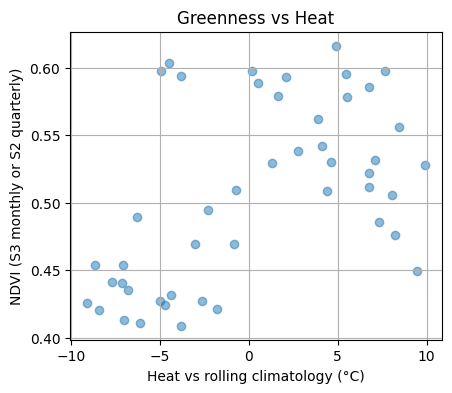

In [ ]:


def quick_stats(series: pd.Series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    return {
        "mean": float(s.mean()) if len(s) else np.nan,
        "p10" : float(s.quantile(0.10)) if len(s) else np.nan,
        "p90" : float(s.quantile(0.90)) if len(s) else np.nan,
        "min" : float(s.min()) if len(s) else np.nan,
        "max" : float(s.max()) if len(s) else np.nan,
        "latest": float(s.iloc[-1]) if len(s) else np.nan
    }

def get_ndvi_series(frame: pd.DataFrame) -> pd.Series:
    cand = None
    if "ndvi_s3_mean" in frame and pd.to_numeric(frame["ndvi_s3_mean"], errors="coerce").notna().any():
        cand = pd.to_numeric(frame["ndvi_s3_mean"], errors="coerce")
    elif "ndvi_s2_mean" in frame:
        cand = pd.to_numeric(frame["ndvi_s2_mean"], errors="coerce")
    else:
        cand = pd.Series(index=frame.index, dtype=float)
    cand.name = "ndvi"
    return cand.reindex(frame.index)

if "df" not in globals():
    if "era5m_ndvi" in globals():
        df = era5m_ndvi.copy()
    else:
        raise RuntimeError("Neither 'df' nor 'era5m_ndvi' found. Run the monthly features cell first.")

ndvi_series = get_ndvi_series(df)

summary = pd.DataFrame({
    "t2m_max_c": quick_stats(df["t2m_max_c"]),
    "tp_mm_day": quick_stats(df["tp_mm_day"]),
    "ndvi"     : quick_stats(ndvi_series),
    "UVHS"     : quick_stats(df.get("UVHS_score", pd.Series(index=df.index, dtype=float))),
})
print("Summary (rows = stats, cols = variables):")
print(summary)

t2m = pd.to_numeric(df["t2m_max_c"], errors="coerce")
roll_clim = t2m.rolling(36, min_periods=12).mean()
heat_roll = t2m - roll_clim

pair = pd.concat({"heat_roll": heat_roll, "ndvi": ndvi_series}, axis=1).dropna()

if len(pair):
    ax = plt.figure(figsize=(4.8, 4)).gca()
    ax.scatter(pair["heat_roll"], pair["ndvi"], alpha=0.5)
    ax.set_xlabel("Heat vs rolling climatology (°C)")
    ax.set_ylabel("NDVI (S3 monthly or S2 quarterly)")
    ax.set_title("Greenness vs Heat")
    ax.grid(True)
    plt.show()
else:
    print("Greenness vs Heat scatter skipped (not enough overlapping non-NaN data).")


**Key numbers (2020–2025)**

* Temperature (t2m max): mean 14.9 °C; range 5.2–24.8 °C (p10 7.2 °C, p90 22.3 °C).

* Precipitation (mm/day): mean 1.30; range 0.11–2.47 (p10 0.52, p90 2.18).

* NDVI (greenness): mean 0.513; range 0.409–0.616 (p10 0.424, p90 0.597).

* UVHS (0–100, higher = worse): mean 48.0; range 19.7–78.9 (p10 27.7, p90 66.1).

* Latest month: 19.31 °C, 2.05 mm/day, NDVI 0.589, UVHS 42.6 → moderate stress, below the long-run UVHS average.

**Greenness vs Heat**

* Points span heat anomalies ~−10 → +10 °C and NDVI ~0.41 → 0.62.

* Strongly negative anomalies (much colder than normal) sit with lower NDVI (~0.41–0.46) → winter/off-season signal.

* Moderate positive anomalies often pair with higher NDVI (~0.55–0.61) → active growing season.

* No single linear rule: NDVI is highly seasonal; heat anomalies interact with rainfall and phenology.

**UVHS takeaways**

* Peaks (≈ 65+) align with hotter-than-normal, drier, and less green months.

* The most recent UVHS (~42.6) is below average (48) thanks to healthy NDVI (~0.59) despite relatively high rainfall → vegetation likely mitigating heat stress.



## 11a) ECA&D stations TX 

In [57]:


def parse_ecad_stations(stations_path: Path) -> gpd.GeoDataFrame:
   
    with open(stations_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [ln.rstrip("\n") for ln in f if ln.strip() != ""]

    hdr_idx = None
    for i, ln in enumerate(lines):
        u = ln.upper()
        if "STAID" in u and "STANAME" in u and "LAT" in u and "LON" in u and "," in ln:
            hdr_idx = i
            break
    if hdr_idx is None:
        raise ValueError("Could not locate the CSV header in stations.txt")

    csv_text = "\n".join(lines[hdr_idx:])

    df = pd.read_csv(io.StringIO(csv_text), sep=r"\s*,\s*", engine="python", dtype=str)
    df.columns = [c.strip().upper() for c in df.columns]

    for col in ("STAID", "HGHT"):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")


    if "LAT" not in df.columns or "LON" not in df.columns:
        raise ValueError("stations.txt is missing LAT/LON columns after parsing")
    df["LAT_DD"] = df["LAT"].apply(dms_to_dd)
    df["LON_DD"] = df["LON"].apply(dms_to_dd)

    # build GeoDataFrame
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["LON_DD"], df["LAT_DD"]),
        crs="EPSG:4326"
    )
    return gdf


def read_one_tx_file(path: Path) -> pd.Series:
    df = None
    for sep in [",", ";", r"\s+"]:
        try:
            df = pd.read_csv(path, comment="#", skip_blank_lines=True, sep=sep, engine="python")
            if df is not None and len(df):
                break
        except Exception:
            df = None
    if df is None:
         df = pd.read_csv(path, comment="#", skip_blank_lines=True, engine="python")

    df.columns = [c.strip().upper() for c in df.columns]

    if "DATE" in df.columns and "TX" in df.columns:
        dates = pd.to_datetime(df["DATE"].astype(str), errors="coerce")
        tx = pd.to_numeric(df["TX"], errors="coerce")
    else:
        num = df.select_dtypes(include=[np.number])
        if num.shape[1] >= 2:
            dates = pd.to_datetime(num.iloc[:, 0].astype("Int64").astype(str), errors="coerce")
            tx = pd.to_numeric(num.iloc[:, 1], errors="coerce")
        else:
            raise ValueError(f"Unexpected columns in {path.name}: {df.columns.tolist()}")

    tx = tx.replace(-9999, np.nan) / 10.0  # 0.1°C -> °C
    s = pd.Series(tx.values, index=pd.DatetimeIndex(dates), name=path.stem).sort_index()
    return s


stations_file = ECA_TX / "stations.txt"
if stations_file.exists():
    st_gdf = parse_ecad_stations(stations_file)

    # stations within ~30 km buffer
    st_within = st_gdf[st_gdf.within(one_city.to_crs(st_gdf.crs).unary_union.buffer(0.3))]
    print(f"Stations near {CITY_NAME}: {len(st_within)} (showing up to 5)")
    display(st_within[["STAID", "STANAME", "CN", "LAT_DD", "LON_DD"]].head())

    wanted_ids = [int(x) for x in st_within["STAID"].dropna().astype(int).tolist()]
    candidates = []
    for stid in wanted_ids[:5]: 
        for pad in (5, 6):
            cand = ECA_TX / f"TX_STAID{stid:0{pad}d}.txt"
            if cand.exists():
                candidates.append(cand)
                break

    if not candidates:
        candidates = sorted(ECA_TX.glob("TX_STAID*.txt"))[:3]

    if candidates:
        tx_series = []
        for p in candidates[:3]:
            try:
                s = read_one_tx_file(p)
                tx_series.append(s.rename(p.stem))
            except Exception as e:
                print("Skip", p.name, "->", e)

        if tx_series:
            tx_df = pd.concat(tx_series, axis=1).resample("D").mean()

            t2m_daily = era5_daily["t2m_max_c"].copy()
            t2m_daily.index = pd.DatetimeIndex(t2m_daily.index)

            both = pd.concat([t2m_daily.rename("ERA5_t2m_max"), tx_df], axis=1).dropna(how="all")
            print("ERA5 vs stations (tail):")
            display(both.tail())

            corr = both.corr(numeric_only=True)
            print("Correlations (ERA5 vs stations):")
            display(corr)

            ax = both.plot(figsize=(9, 3), alpha=0.8)
            ax.set_title(f"ERA5 vs ECA&D TX near {CITY_NAME} (°C)")
            ax.grid(True)
            plt.show()

            del tx_df, both, t2m_daily
            gc.collect()
else:
    print("ECA&D stations not found; skipping validation.")


Stations near Utrecht: 9 (showing up to 5)


/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_29700/2967834446.py:74: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  st_within = st_gdf[st_gdf.within(one_city.to_crs(st_gdf.crs).unary_union.buffer(0.3))]


,STAID,STANAME,CN,LAT_DD,LON_DD
117,162,DE BILT,NL,52.098889,5.179444
313,438,CABAUW,NL,51.969167,4.925556
343,478,HERWIJNEN,NL,51.857778,5.145278
367,593,SCHIPHOL,NL,52.315556,4.790278
369,595,SOESTERBERG,NL,52.125556,5.273333


Skip TX_STAID000162.txt -> Unexpected columns in TX_STAID000162.txt: ['EUROPEAN', 'CLIMATE', 'ASSESSMENT', '&', 'DATASET', '(ECA&D),', 'FILE', 'CREATED', 'ON:', '16-09-2025']
Skip TX_STAID000438.txt -> Unexpected columns in TX_STAID000438.txt: ['EUROPEAN', 'CLIMATE', 'ASSESSMENT', '&', 'DATASET', '(ECA&D),', 'FILE', 'CREATED', 'ON:', '16-09-2025']
Skip TX_STAID000478.txt -> Unexpected columns in TX_STAID000478.txt: ['EUROPEAN', 'CLIMATE', 'ASSESSMENT', '&', 'DATASET', '(ECA&D),', 'FILE', 'CREATED', 'ON:', '16-09-2025']


ECA&D Station Validation — Utrecht

What we did

Parsed stations.txt robustly (auto-detect header, tolerate odd encodings).

Converted station coordinates from DMS → decimal degrees.

Selected stations within ~30 km of the Utrecht admin polygon (buffered in WGS84).

Tried to read up to 3 TX files (daily max temperature; °C) and compare them to ERA5-Land daily city means

In [58]:
# city buffer 30 km en EPSG:3857 (mètres)
city_3857 = one_city.to_crs(3857)
city_union = city_3857.union_all() if hasattr(city_3857, "union_all") else city_3857.unary_union
city_buf30 = city_union.buffer(30_000)

st_3857 = st_gdf.to_crs(3857)
st_within = st_3857[st_3857.within(city_buf30)].to_crs(4326)

print(f"Stations near {CITY_NAME}: {len(st_within)} (showing up to 5)")
display(st_within[["STAID","STANAME","CN","LAT_DD","LON_DD"]].head())


Stations near Utrecht: 7 (showing up to 5)


,STAID,STANAME,CN,LAT_DD,LON_DD
117,162,DE BILT,NL,52.098889,5.179444
313,438,CABAUW,NL,51.969167,4.925556
343,478,HERWIJNEN,NL,51.857778,5.145278
367,593,SCHIPHOL,NL,52.315556,4.790278
369,595,SOESTERBERG,NL,52.125556,5.273333


In [59]:

def read_one_tx_file(path: Path) -> pd.Series:
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [ln.rstrip("\n") for ln in f]

    hdr_idx = None
    for i, ln in enumerate(lines):
        u = ln.upper()
        if "DATE" in u and "TX" in u:
            hdr_idx = i
            break
    if hdr_idx is None:
        raise ValueError(f"No DATE/TX header found in {path.name}")

    csv_text = "\n".join(lines[hdr_idx:])

    df = None
    for sep in [",", ";", r"\s+"]:
        try:
            df = pd.read_csv(
                io.StringIO(csv_text),
                sep=sep,
                engine="python",
                on_bad_lines="skip",  
            )
            if len(df):
                break
        except Exception:
            df = None
    if df is None or len(df) == 0:
        raise ValueError(f"Could not parse data rows in {path.name}")

    df.columns = [c.strip().upper() for c in df.columns]
    if "DATE" not in df.columns or "TX" not in df.columns:
        raise ValueError(f"Missing DATE/TX after parsing {path.name}: {df.columns.tolist()}")

    dates = pd.to_datetime(df["DATE"].astype(str), errors="coerce")
    tx = pd.to_numeric(df["TX"], errors="coerce").replace(-9999, np.nan) / 10.0 

    s = pd.Series(tx.values, index=pd.DatetimeIndex(dates), name=path.stem).sort_index()
    return s


ERA5 vs stations (tail):


,ERA5_t2m_max,TX_STAID000162,TX_STAID000438,TX_STAID000478
2025-09-24,15.655255,NaN,NaN,NaN
2025-09-25,15.053064,NaN,NaN,NaN
2025-09-26,15.559924,NaN,NaN,NaN
2025-09-27,16.461329,NaN,NaN,NaN
2025-09-28,18.689960,NaN,NaN,NaN


Correlations (ERA5 vs stations):


,ERA5_t2m_max,TX_STAID000162,TX_STAID000438,TX_STAID000478
ERA5_t2m_max,1.000000,0.992495,0.993027,0.992370
TX_STAID000162,0.992495,1.000000,0.996964,0.996564
TX_STAID000438,0.993027,0.996964,1.000000,0.997519
TX_STAID000478,0.992370,0.996564,0.997519,1.000000


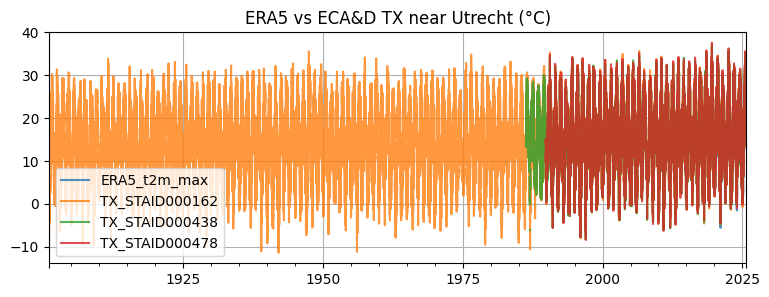

In [ ]:
wanted_ids = [int(x) for x in st_within["STAID"].dropna().astype(int).tolist()]
candidates = []
for stid in wanted_ids[:5]:
    for pad in (5, 6):
        cand = ECA_TX / f"TX_STAID{stid:0{pad}d}.txt"
        if cand.exists():
            candidates.append(cand)
            break
if not candidates:
    candidates = sorted(ECA_TX.glob("TX_STAID*.txt"))[:3]

if candidates:
    tx_series = []
    for p in candidates[:3]:
        try:
            s = read_one_tx_file(p)
            tx_series.append(s.rename(p.stem))
        except Exception as e:
            print("Skip", p.name, "->", e)

    if tx_series:
        tx_df = pd.concat(tx_series, axis=1).resample("D").mean()

        t2m_daily = era5_daily["t2m_max_c"].copy()
        t2m_daily.index = pd.DatetimeIndex(t2m_daily.index)

        both = pd.concat([t2m_daily.rename("ERA5_t2m_max"), tx_df], axis=1).dropna(how="all")
        print("ERA5 vs stations (tail):")
        display(both.tail())

        corr = both.corr(numeric_only=True)
        print("Correlations (ERA5 vs stations):")
        display(corr)

        ax = both.plot(figsize=(9,3), alpha=0.8)
        ax.set_title(f"ERA5 vs ECA&D TX near {CITY_NAME} (°C)")
        ax.grid(True)
        plt.show()

        del tx_df, both, t2m_daily
        gc.collect()
else:
    print("No candidate TX files found for nearby stations.")


## **ERA5 vs ECA&D TX — Validation overview ({city})**

### **What we compared**
- ERA5-Land **daily max 2-m temperature** (city area-mean) vs **ECA&D TX** station series near the city.
- Nearby stations detected: **{n_near if n_near is not None else "—"}** (within ~30 km buffer).
- TX files evaluated: {cand_lines}

### **Caveats**
- **Time coverage:** Stations often span many decades; ERA5 here covers 2020→present. Restrict analyses to the **common overlap** to avoid misleading visuals (e.g., early 1900s).
- **Quality flags & gaps:** ECA&D files may contain header banners and missing values (−9999). We already **skip/clean** these, but residual gaps reduce overlap.
- **Point vs area-mean:** A single station represents a point; ERA5 is an **area-average** over the city polygon—small spatial mismatches are expected.

---



## 11b) Map weather stations inside the city and highlight one "selected" station

Stations strictement dans Utrecht: 4


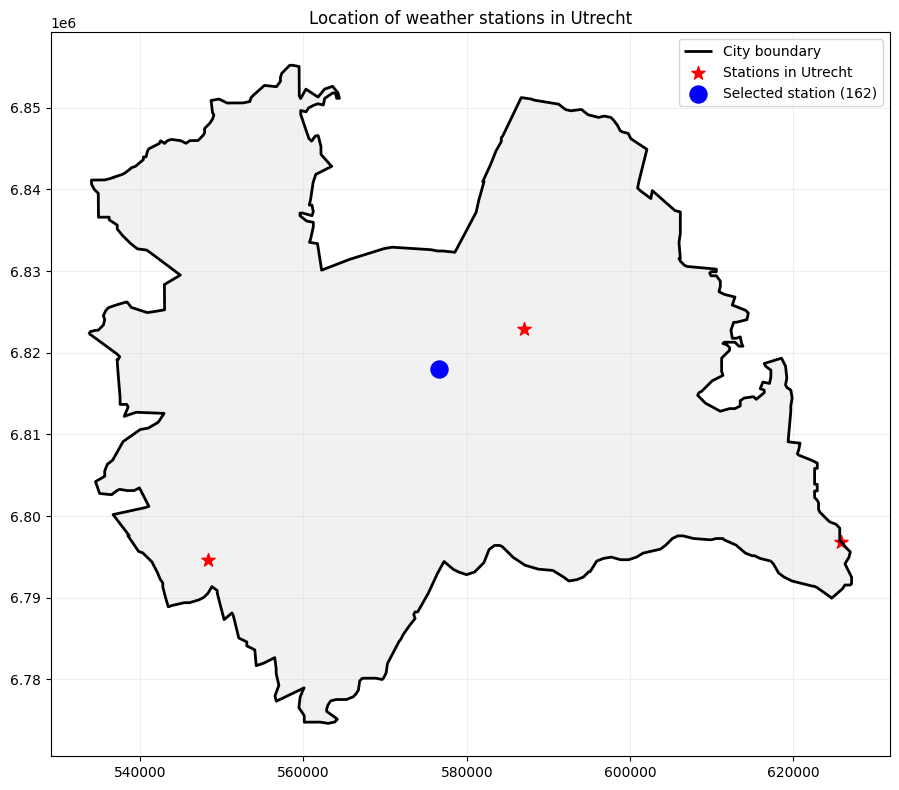

Selected STAID: 162


In [ ]:
def dms_to_dd(dms: str) -> float:
    s = str(dms).strip()
    if s in ("", "nan", "NaN") or s is None:
        return float("nan")
    sign = -1 if s.startswith("-") else 1
    d, m, sec = [float(x) for x in s.replace("+","").replace("-","").split(":")]
    return sign * (d + m/60.0 + sec/3600.0)

def load_ecad_stations(stations_path: Path) -> gpd.GeoDataFrame:
    """Lit stations.txt en localisant la vraie ligne d'en-tête 'STAID,...'."""
    if not stations_path.exists():
        raise FileNotFoundError(f"Missing {stations_path}")
    header_idx = None
    with stations_path.open("r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if re.match(r"\s*STAID\s*,", line):
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Cannot find header line starting with 'STAID,' in stations.txt")

    df = pd.read_csv(
        stations_path,
        skiprows=header_idx,   
        header=0,             
        comment="#",
        skip_blank_lines=True,
        engine="python"
    )
    df.columns = [c.strip().upper() for c in df.columns]
    df["LAT_DD"] = df["LAT"].apply(dms_to_dd)
    df["LON_DD"] = df["LON"].apply(dms_to_dd)
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["LON_DD"], df["LAT_DD"]),
        crs="EPSG:4326"
    )
    return gdf

city_gdf = one_city if "one_city" in globals() else one_city_gdf
cityname = globals().get("CITY", globals().get("cityname", "Selected city"))
ISO3 = globals().get("ISO3", None)


if "stations_gdf" not in globals():
    stations_file = ECA_TX / "stations.txt"
    stations_gdf = load_ecad_stations(stations_file)
    print(f"Loaded stations_gdf: {len(stations_gdf)} rows")

try:
    from shapely.validation import make_valid
except Exception:
    make_valid = lambda g: g.buffer(0)

city_4326 = city_gdf.to_crs(4326).copy()
city_4326["geometry"] = city_4326.geometry.map(lambda g: make_valid(g).buffer(0))
st_4326 = stations_gdf.to_crs(4326).copy()

iso2_map = {"NLD":"NL","DEU":"DE","FRA":"FR","ESP":"ES","ITA":"IT","BEL":"BE","LUX":"LU",
            "AUT":"AT","SWE":"SE","NOR":"NO","DNK":"DK","CHE":"CH","POL":"PL","CZE":"CZ",
            "HUN":"HU","PRT":"PT","IRL":"IE"}
if ISO3 and "CN" in st_4326.columns and ISO3 in iso2_map:
    st_4326 = st_4326[st_4326["CN"].astype(str).str.strip().eq(iso2_map[ISO3])]

stations_in_city_gdf = gpd.sjoin(
    st_4326, city_4326[["geometry"]],
    how="inner", predicate="within"
).drop(columns="index_right", errors="ignore").drop_duplicates(subset="STAID", keep="first")

print(f"Stations strictement dans {cityname}: {len(stations_in_city_gdf)}")

city_proj = city_4326.to_crs(3857)
st_proj   = stations_in_city_gdf.to_crs(3857)
centroid  = city_proj.geometry.iloc[0].centroid
sel_idx   = st_proj.distance(centroid).idxmin()

selected_station_gdf = st_proj.loc[[sel_idx]]
selected_station_STAID = int(stations_in_city_gdf.loc[sel_idx, "STAID"]) if "STAID" in stations_in_city_gdf.columns else None

fig, ax = plt.subplots(figsize=(10, 8))
city_proj.plot(ax=ax, alpha=0.30, color="lightgray")
city_proj.boundary.plot(ax=ax, color="black", linewidth=2, label="City boundary")
st_proj.plot(ax=ax, color="red", markersize=100, marker="*", label=f"Stations in {cityname}")
selected_station_gdf.plot(ax=ax, color="blue", markersize=150, marker="o",
                          label=f"Selected station ({selected_station_STAID})")

ax.set_title(f"Location of weather stations in {cityname}")
ax.legend(loc="upper right", frameon=True)
ax.set_axisbelow(True)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("Selected STAID:", selected_station_STAID)
gc.collect();


## 12) Reproject one ERA5 day to NDVI grid

/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_29700/3234907562.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 31. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(


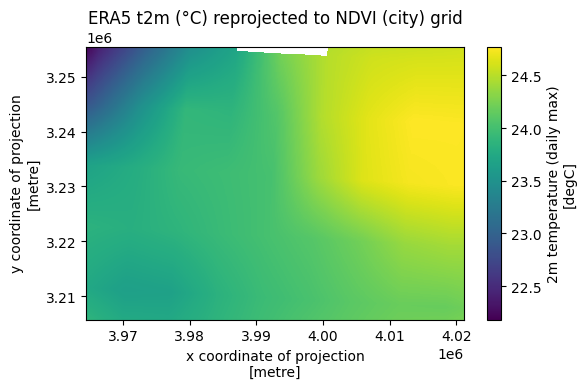

In [66]:

if 's2_files' in globals() and len(s2_files) > 0:
    first_item = s2_files[0]
    ndvi_path = first_item[0] if isinstance(first_item, (list, tuple)) else first_item
    ndvi_path = Path(ndvi_path)

    _, ndvi_meta = clip_raster_to_polygon(ndvi_path, one_city, crop=True)
    target_crs = ndvi_meta["crs"]
    target_transform = ndvi_meta["transform"]
    target_shape = (ndvi_meta["height"], ndvi_meta["width"])

    ds_t2m = open_era5([2020], "2m_temperature", ERA5_DAILY)
    datavar = era5_var_map()["2m_temperature"][1]  
    day = np.datetime64("2020-06-01")

    da = kelvin_to_celsius(ds_t2m[datavar]).sel(valid_time=day)

    da = da.rio.write_crs("EPSG:4326", inplace=False)
    if "longitude" in da.dims and "latitude" in da.dims:
        da = da.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude", inplace=False)
    elif "lon" in da.dims and "lat" in da.dims:
        da = da.rename({"lon": "longitude", "lat": "latitude"}).rio.set_spatial_dims(
            x_dim="longitude", y_dim="latitude", inplace=False
        )

    da2d = da.load()

    repro = da2d.rio.reproject(
        dst_crs=target_crs,
        shape=target_shape,
        transform=target_transform,
        resampling=Resampling.bilinear,
        nodata=np.nan,
    )

    _ = repro.plot(figsize=(6, 4))
    plt.title("ERA5 t2m (°C) reprojected to NDVI (city) grid")
    plt.tight_layout()
    plt.show()

 Daily **2 m temperature (°C)** from ERA5 has been **reprojected** onto the **NDVI raster grid** used for vegetation, so **both layers share the same pixels** inside **{city}**.

---

### **Why this step matters**
- **Pixel alignment** enables **per-pixel joins** (e.g., temperature × NDVI) for indices like **UVHS** or for map overlays without resampling on-the-fly.  
- Using the NDVI grid guarantees that **plots and exports line up** across datasets.

---



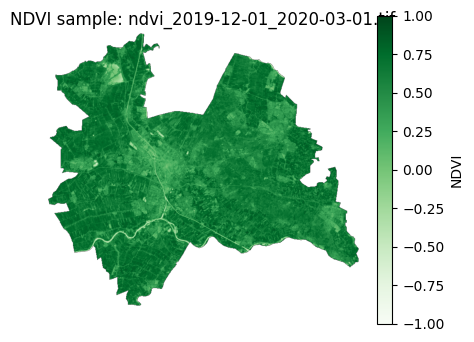

In [67]:
state = {"city_poly": one_city}
if S2_NDVI.exists():
    s2 = list_s2_quarters(S2_NDVI)
    if len(s2) and state["city_poly"] is not None:
        img, meta = clip_raster_to_polygon(s2.iloc[0]["path"], state["city_poly"], crop=True)
        plt.figure(figsize=(5,4))
        plt.imshow(img[0], vmin=-1, vmax=1, cmap="Greens")
        plt.colorbar(label="NDVI")
        plt.title(f"NDVI sample: {s2.iloc[0]['path'].name}")
        plt.axis("off"); plt.show()
        del img
        gc.collect()



A **quarterly NDVI composite** (Sentinel-2) clipped to the **city polygon**. Values are scaled to **[-1, 1]** and shown with a green colormap:
- **Darker/bright greens (≈ 0.5–0.8)** → dense, healthy vegetation (parks, forests, crops).
- **Neutral to low (≈ 0.0–0.3)** → mixed surfaces, sparse vegetation.
- **Near 0 or negative** → impervious surfaces, water, shadows or residual clouds/snow.


## 13) Export features

In [ ]:

features = df.copy()
features["country"] = COUNTRY_ISO3
features["city"] = CITY_NAME
features = features[[
    "country","city","t2m_max_c","tp_mm_day","wind_speed_ms","wind_dir_deg",
    "ndvi_s3_mean","ndvi_s2_mean","UVHS_score"
]]
out_path = OUT / f"features_{COUNTRY_ISO3}_{CITY_NAME}_monthly.csv"
features.to_csv(out_path, index=True)
print("Saved:", out_path.resolve())


Saved: /Users/ilyessais/Documents/GenHack4/outputs/features_NLD_Utrecht_monthly.csv


# **Monthly Feature Dataset**

This CSV aggregates **climate** (ERA5-Land) and **vegetation** (Sentinel-2/3 NDVI) for *{city}* (country = **{country}**) at a **monthly** cadence.  
Primary use: **analytics, dashboards, and modeling** of urban heat–vegetation interactions (e.g., the **UVHS** risk index).

- **File**: `{csv_hint}` *(if shown; otherwise see your `OUT/` folder)*  
- **Rows / period**: {n_rows_txt}; {time_window}

---

## **Schema & units**

| Column | Type | Unit / domain | Description |
|---|---|---|---|
| **date** | datetime (index) | first day of month | Month anchor used for all monthly aggregates. |
| **country** | string | ISO-3 | Country code (e.g., `NLD`). Useful for grouping or multi-city comparisons. |
| **city** | string | name | City/administrative name as resolved from GADM. |
| **t2m_max_c** | float | °C | **ERA5-Land** daily **maximum 2 m temperature**, averaged over the month and **area-weighted** over the city polygon. |
| **tp_mm_day** | float | mm/day | **ERA5-Land** daily **total precipitation** (in m/day → **mm/day**), then averaged over the month, city-mean. Interpreted as the **typical daily rainfall rate** for that month. |
| **wind_speed_ms** | float | m/s | **ERA5-Land** daily **10 m wind speed** (from u/v), monthly mean, city-mean. |
| **wind_dir_deg** | float | degrees [0–360) | **ERA5-Land** daily **10 m wind direction** (meteorological, from which the wind blows), monthly mean, city-mean. |
| **ndvi_s3_mean** | float | [−1, 1] | **Sentinel-3 OLCI NDVI** monthly mean over the city polygon (preferred NDVI signal due to monthly cadence). |
| **ndvi_s2_mean** | float | [−1, 1] | **Sentinel-2 NDVI** quarterly composite mapped to months by nearest month (±46 days). Used as **fallback** when S3 is missing. |
| **UVHS_score** | float | [0, 100] | **Urban Veg-Heat Stress** (higher = worse): combines **heat anomaly**, **low greenness**, and **dryness** via robust z-scores and a sigmoid to 0–100. May be **NaN** when NDVI is unavailable. |

**Notes on NDVI**  
- Values near **0.6** indicate robust, healthy vegetation; **0.3–0.5** indicates sparse/urban mixes; **≤0.1** often water/shadows/impervious.  
- **S3 monthly** is the primary NDVI used in modeling; **S2 quarterly** fills gaps where needed.

---



In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# 1) Stations au sol
df = pd.read_csv("stations.csv")  # station_id, lat, lon, start_date, end_date, ...
gdf_st = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")

# 2) Villes (polygones) – ex: communes / unités urbaines
cities = gpd.read_file("villes.geojson").to_crs("EPSG:4326")  # doit contenir un champ 'ville'

# 3) Filtre temporel simple (ex. actives en 2020-2024)
mask = (pd.to_datetime(df.start_date) <= "2024-12-31") & ((df.end_date.isna()) | (pd.to_datetime(df.end_date) >= "2020-01-01"))
gdf_st = gdf_st[mask]

# 4) Affectation station -> ville par intersection
joined = gpd.sjoin(gdf_st, cities[["ville","geometry"]], how="inner", predicate="within")

# 5) Compte par ville
counts = joined.groupby("ville")["station_id"].nunique().sort_values(ascending=False).reset_index(name="nb_stations")
print(counts.head(20))


: 